# 03 — Landslide Severity Index (LSI)

A first-draft **0-10 severity scale**, analogous in spirit to the Richter scale for
earthquakes but built differently on purpose:

Richter's scale is **logarithmic** because seismic energy spans many orders of
magnitude and is derived from a physical wave-amplitude measurement. This prototype has
no equivalent physical quantity yet — no debris volume, runout distance, or energy
estimate exists in the (synthetic) data — so imposing a log transform on bounded [0,1]
inputs would fabricate false precision that isn't there. Instead LSI is a **transparent,
linear, weighted composite** of the model's predicted probability plus three factor
magnitudes:

```
LSI = 10 x clip(0.45*P_ml + 0.25*Rainfall_norm + 0.20*History_norm + 0.10*Soil_weight, 0, 1)
```

If/when real volumetric or energy-related impact data becomes available, a log or
power-law term could be justified — see the discussion at the end of this notebook.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from landslide_toy import config, severity, viz

viz.set_style()
df = pd.read_csv(ROOT / "data" / "synthetic" / "nuwara_eliya_synthetic_sites.csv")
bundle = joblib.load(ROOT / "outputs" / "models" / "best_model.joblib")
print("Loaded model:", bundle["model_name"], "on", bundle["feature_set_name"])


Loaded model: XGBoost on Set A (soil+rainfall+history)


## 1. Recompute model probability for every site

For this demonstration we score the **entire** synthetic dataset (not just the held-out
test split) so the LSI examples below can span the full range of sites. This means some
probabilities come from sites the model was trained on — fine for illustrating the
index, but notebook 02's held-out metrics remain the only valid measure of predictive
performance.

In [2]:
def encode(frame, categorical_cols, numeric_cols):
    dummies = pd.get_dummies(frame[categorical_cols].astype(str), prefix=categorical_cols)
    numeric = frame[numeric_cols].reset_index(drop=True)
    return pd.concat([numeric, dummies.reset_index(drop=True)], axis=1)


X_full = encode(df, bundle["categorical_cols"], bundle["numeric_cols"])
X_full = X_full.reindex(columns=bundle["feature_columns"], fill_value=0)

df["p_ml"] = bundle["model"].predict_proba(X_full)[:, 1]
df[["site_id", "division", "p_ml"]].head()


,site_id,division,p_ml
0,KOT-0107,Kotmale,0.065626
1,KOT-0144,Kotmale,0.080297
2,WAL-0117,Walapane,0.098372
3,WAL-0030,Walapane,0.022169
4,KOT-0115,Kotmale,0.129954


## 2. Compute the Landslide Severity Index

In [3]:
breakdown = severity.compute_lsi_breakdown(
    p_ml=df["p_ml"],
    max_24h_rainfall_mm=df["max_24h_rainfall_mm"],
    historical_failure_density_per_km2=df["historical_failure_density_per_km2"],
    soil_weight=df["soil_weight"],
)
df = pd.concat([df, breakdown], axis=1)
df[["site_id", "division", "p_ml", "lsi", "lsi_band"]].sort_values("lsi", ascending=False).head(10)


,site_id,division,p_ml,lsi,lsi_band
374,AMB-0040,Ambagamuwa,0.930694,8.798210,Severe/Critical
226,AMB-0125,Ambagamuwa,0.832891,7.998009,Major
107,WAL-0104,Walapane,0.781221,7.165494,Major
273,AMB-0108,Ambagamuwa,0.545128,7.150035,Major
236,AMB-0088,Ambagamuwa,0.794978,7.140930,Major
260,KOT-0004,Kotmale,0.809839,6.989321,Major
441,KOT-0149,Kotmale,0.770519,6.894207,Major
112,KOT-0005,Kotmale,0.717762,6.877997,Major
71,WAL-0025,Walapane,0.766630,6.843611,Major
325,AMB-0065,Ambagamuwa,0.720049,6.837554,Major


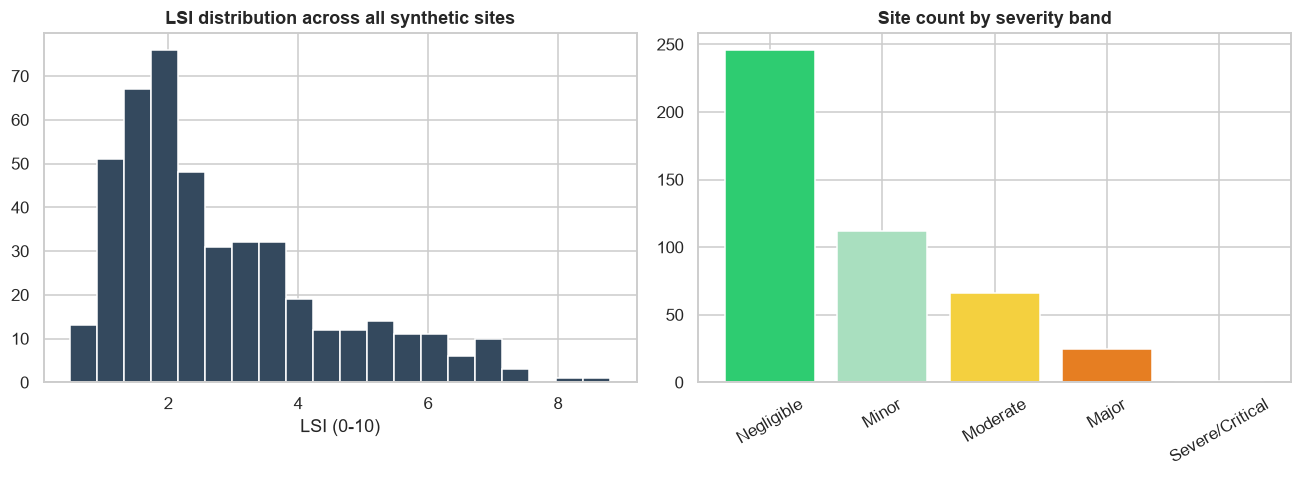

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["lsi"], bins=20, color="#34495E", edgecolor="white")
axes[0].set_title("LSI distribution across all synthetic sites")
axes[0].set_xlabel("LSI (0-10)")

band_order = [b for _, _, b in config.LSI_BANDS]
band_counts = df["lsi_band"].value_counts().reindex(band_order, fill_value=0)
axes[1].bar(band_counts.index, band_counts.values,
            color=[viz.BAND_COLORS[b] for b in band_counts.index])
axes[1].set_title("Site count by severity band")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 3. Example sites spanning the scale

In [5]:
df_sorted = df.sort_values("lsi").reset_index(drop=True)
n = len(df_sorted)
example_positions = sorted(set([0, n // 4, n // 2, int(n * 0.75), n - 1]))
examples = df_sorted.iloc[example_positions].copy()

display_cols = ["site_id", "division", "soil_type", "slope_deg", "max_24h_rainfall_mm",
                 "historical_failure_count_20yr", "p_ml", "lsi", "lsi_band"]
examples[display_cols].round(2)


,site_id,division,soil_type,slope_deg,max_24h_rainfall_mm,historical_failure_count_20yr,p_ml,lsi,lsi_band
0,WAL-0100,Walapane,Reddish-Brown Latosolic,3.00,8.85,0,0.01,0.50,Negligible
112,WAL-0129,Walapane,Mountain Regosol,32.69,28.42,2,0.06,1.61,Negligible
225,AMB-0072,Ambagamuwa,Mountain Regosol,30.96,55.79,3,0.10,2.34,Negligible
337,WAL-0084,Walapane,Red-Yellow Podzolic,27.53,41.83,5,0.31,3.68,Minor
449,AMB-0040,Ambagamuwa,Red-Yellow Podzolic,36.41,180.81,8,0.93,8.80,Severe/Critical


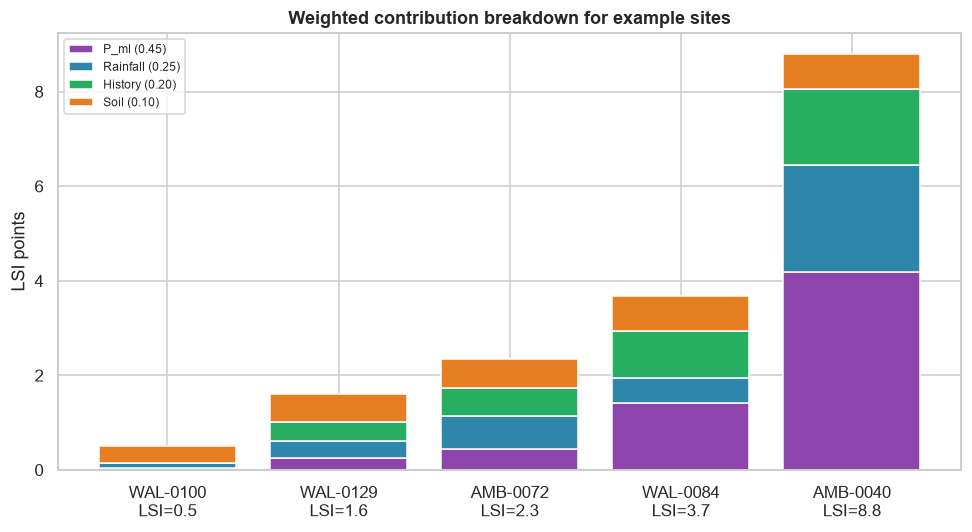

In [6]:
contrib_cols = ["contrib_p_ml", "contrib_rainfall", "contrib_history", "contrib_soil"]
contrib_labels = ["P_ml (0.45)", "Rainfall (0.25)", "History (0.20)", "Soil (0.10)"]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(examples))
colors = ["#8E44AD", "#2E86AB", "#27AE60", "#E67E22"]
labels_x = [f"{row.site_id}\nLSI={row.lsi:.1f}" for row in examples.itertuples()]
for col, label, color in zip(contrib_cols, contrib_labels, colors):
    ax.bar(labels_x, examples[col], bottom=bottom, label=label, color=color)
    bottom += examples[col].to_numpy()

ax.set_ylabel("LSI points")
ax.set_title("Weighted contribution breakdown for example sites")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4. LSI is not just the raw probability

The scatter below shows LSI against the raw ML probability `P_ml`. If LSI were simply a
rescaled probability the points would fall on a single line; instead sites with similar
`P_ml` can land at different LSI values depending on rainfall/history/soil — which is
the point of layering severity on top of an occurrence estimate.

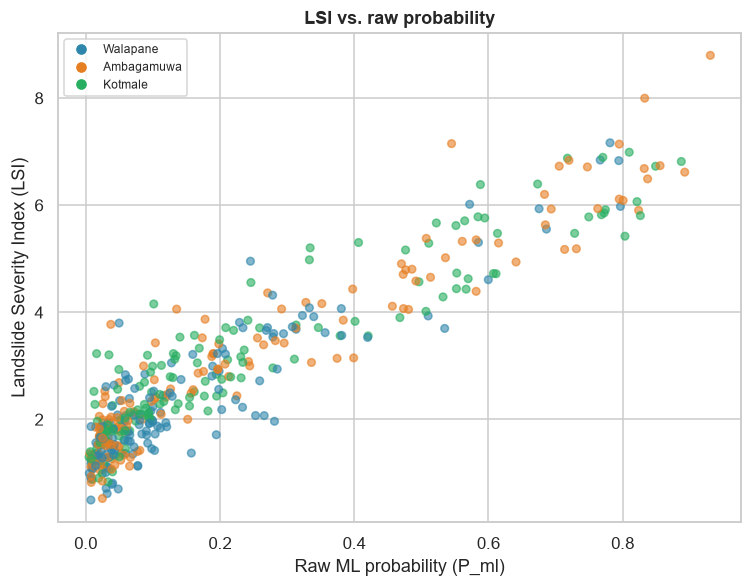

Sites with similar P_ml (bin (0.499, 0.56]) but LSI spread of 3.45 points:


,site_id,division,p_ml,max_24h_rainfall_mm,historical_failure_density_per_km2,soil_type,lsi,lsi_band
372,WAL-0043,Walapane,0.53,27.39,1.0,Red-Yellow Podzolic,3.70,Minor
273,AMB-0108,Ambagamuwa,0.55,155.76,10.0,Red-Yellow Podzolic,7.15,Major


In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(df["p_ml"], df["lsi"], c=df["division"].map(viz.DIVISION_COLORS), alpha=0.6, s=25)
ax.set_xlabel("Raw ML probability (P_ml)")
ax.set_ylabel("Landslide Severity Index (LSI)")
ax.set_title("LSI vs. raw probability")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=d)
           for d, c in viz.DIVISION_COLORS.items()]
ax.legend(handles=handles, fontsize=8)
plt.tight_layout()
plt.show()

# Find a pair of sites with near-identical P_ml but the largest LSI gap, to make the
# "LSI != probability" point concrete with an actual example from this dataset.
df["p_ml_bin"] = pd.cut(df["p_ml"], bins=15)
bin_spread = df.groupby("p_ml_bin", observed=True)["lsi"].agg(["min", "max", "count"])
bin_spread["spread"] = bin_spread["max"] - bin_spread["min"]
best_bin = bin_spread[bin_spread["count"] >= 2].sort_values("spread", ascending=False).index[0]
pair = df[df["p_ml_bin"] == best_bin].sort_values("lsi")
pair_example = pd.concat([pair.head(1), pair.tail(1)])
print(f"Sites with similar P_ml (bin {best_bin}) but LSI spread of "
      f"{bin_spread.loc[best_bin, 'spread']:.2f} points:")
pair_example[["site_id", "division", "p_ml", "max_24h_rainfall_mm",
              "historical_failure_density_per_km2", "soil_type", "lsi", "lsi_band"]].round(2)


## 5. Weight sensitivity on one example site

In [8]:
probe = examples.iloc[len(examples) // 2]
base_weights = {
    "p_ml": config.LSI_WEIGHT_P_ML, "rainfall": config.LSI_WEIGHT_RAINFALL,
    "history": config.LSI_WEIGHT_HISTORY, "soil": config.LSI_WEIGHT_SOIL,
}
sensitivity_rows = []
for key in base_weights:
    for pct in [-0.20, 0.0, 0.20]:
        weights = dict(base_weights)
        weights[key] = base_weights[key] * (1 + pct)
        hist_min = df["historical_failure_density_per_km2"].min()
        hist_max = df["historical_failure_density_per_km2"].max()
        norm_components = {
            "p_ml": probe["p_ml"],
            "rainfall": severity.rainfall_norm(probe["max_24h_rainfall_mm"]),
            "history": severity.history_norm(
                np.array([probe["historical_failure_density_per_km2"]]), hist_min, hist_max
            )[0],
            "soil": probe["soil_weight"],
        }
        composite = float(sum(weights[k] * norm_components[k] for k in weights))
        composite = min(max(composite, 0.0), 1.0)
        sensitivity_rows.append({
            "weight_varied": key, "pct_change": pct, "lsi": round(10 * composite, 2),
        })

sens_df = pd.DataFrame(sensitivity_rows).pivot(index="weight_varied", columns="pct_change", values="lsi")
print(f"Base site: {probe['site_id']} (baseline LSI = {probe['lsi']:.2f})")
sens_df


Base site: AMB-0072 (baseline LSI = 2.34)


pct_change,-0.2,0.0,0.2
weight_varied,,,
history,2.22,2.34,2.46
p_ml,2.25,2.34,2.43
rainfall,2.20,2.34,2.48
soil,2.22,2.34,2.46


## 6. Discussion

- LSI bands used here: 0-2.5 Negligible, 2.5-4.0 Minor, 4.0-6.0 Moderate, 6.0-8.0 Major,
  8.0-10.0 Severe/Critical — matching the "8.0 = severe / 4.0 = minor" framing from the
  original research goal.
- The weights (0.45 / 0.25 / 0.20 / 0.10) are **author-assigned, not fitted** — a
  documented first draft. The sensitivity table above shows the index is reasonably
  stable to +/-20% perturbation of any single weight, but this should be revisited once
  the winning feature set from notebook 02 is validated on real data.
- A future version with access to real debris volume, runout, or fatality/damage records
  could justify a logarithmic or power-law severity term, making the "Richter-style"
  analogy more literal than it currently is.

**Next:** `04_shap_explainability.ipynb` explains individual `P_ml` predictions with
SHAP, producing a real data-driven version of the site's illustrative
Soil/History/Rainfall percentage split.